# Análise de Tráfego - Jaraguá do Sul

**Wanderley Junior Alves Trindade**  
30 dias de dados | 23.000+ medições | 8 rotas monitoradas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar dados (funciona tanto no notebook quanto no terminal)
if os.path.exists('../data/processed'):
    csv_files = glob.glob('../data/processed/traffic_data_cleaned_*.csv')
else:
    csv_files = glob.glob('data/processed/traffic_data_cleaned_*.csv')

if not csv_files:
    raise FileNotFoundError("Nenhum arquivo de dados encontrado!")

df = pd.read_csv(max(csv_files, key=lambda x: x))
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"✓ Dataset carregado: {len(df):,} registros")
print(f"✓ Período: {df['timestamp'].min().date()} a {df['timestamp'].max().date()}")
print(f"✓ Rotas: {df['route_name'].nunique()}")

Dataset: 23,039 registros | 2026-03-01 a 2026-03-30


## Resumo Executivo

In [2]:
print("═" * 60)
print("PRINCIPAIS DESCOBERTAS")
print("═" * 60)

# Estatísticas gerais
print(f"\n1. CONGESTIONAMENTO GERAL")
print(f"   Média: {df['congestion_index'].mean():.1f}%")
print(f"   Máximo: {df['congestion_index'].max():.1f}%")

# Pico horário
hourly = df.groupby('hour_of_day')['congestion_index'].mean()
peak_hour = hourly.idxmax()
peak_value = hourly.max()
print(f"\n2. PICO DE CONGESTIONAMENTO")
print(f"   Horário: {int(peak_hour)}h")
print(f"   Intensidade: {peak_value:.1f}%")

# Pior dia
days = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
weekly = df.groupby('day_of_week')['congestion_index'].mean()
worst_day_idx = weekly.idxmax()
print(f"\n3. DIA MAIS CRÍTICO")
print(f"   Dia: {days[worst_day_idx]}")
print(f"   Congestionamento: {weekly.max():.1f}%")

# Rota pior
routes = df.groupby('route_name').agg({
    'delay_seconds': 'mean',
    'congestion_index': 'mean'
}).sort_values('delay_seconds', ascending=False)
print(f"\n4. ROTA MAIS PROBLEMÁTICA")
print(f"   Rota: {routes.index[0]}")
print(f"   Atraso médio: {routes.iloc[0]['delay_seconds']:.0f}s ({routes.iloc[0]['delay_seconds']/60:.1f} min)")
print(f"   Congestionamento: {routes.iloc[0]['congestion_index']:.1f}%")

# Rush hour
rush = df[df['is_rush_hour']]['congestion_index'].mean()
normal = df[~df['is_rush_hour']]['congestion_index'].mean()
increase = ((rush - normal) / normal * 100)
print(f"\n5. IMPACTO DO RUSH HOUR")
print(f"   Aumento: {increase:.1f}% pior que horário normal")
print(f"   Normal: {normal:.1f}% | Rush: {rush:.1f}%")

# Correlações
corr = df[['delay_seconds', 'is_rush_hour', 'is_weekend', 'congestion_index']].corr()['congestion_index'].drop('congestion_index')
print(f"\n6. PRINCIPAIS CORRELAÇÕES")
print(f"   Atraso: {corr['delay_seconds']:.2f} (fortíssima)")
print(f"   Rush hour: {corr['is_rush_hour']:.2f} (forte)")
print(f"   Fim de semana: {corr['is_weekend']:.2f} (reduz)")

print("\n" + "═" * 60)

════════════════════════════════════════════════════════════
PRINCIPAIS DESCOBERTAS
════════════════════════════════════════════════════════════

1. CONGESTIONAMENTO GERAL
   Média: 37.5%
   Máximo: 100.0%

2. PICO DE CONGESTIONAMENTO
   Horário: 18h
   Intensidade: 81.0%

3. DIA MAIS CRÍTICO
   Dia: Quinta
   Congestionamento: 45.3%

4. ROTA MAIS PROBLEMÁTICA
   Rota: BR-280 (Sul → Norte)
   Atraso médio: 222s (3.7 min)
   Congestionamento: 41.4%

5. IMPACTO DO RUSH HOUR
   Aumento: 231.1% pior que horário normal
   Normal: 26.7% | Rush: 88.3%

6. PRINCIPAIS CORRELAÇÕES
   Atraso: 0.93 (fortíssima)
   Rush hour: 0.79 (forte)
   Fim de semana: -0.39 (reduz)

════════════════════════════════════════════════════════════


## Visualização 1: Padrão Diário

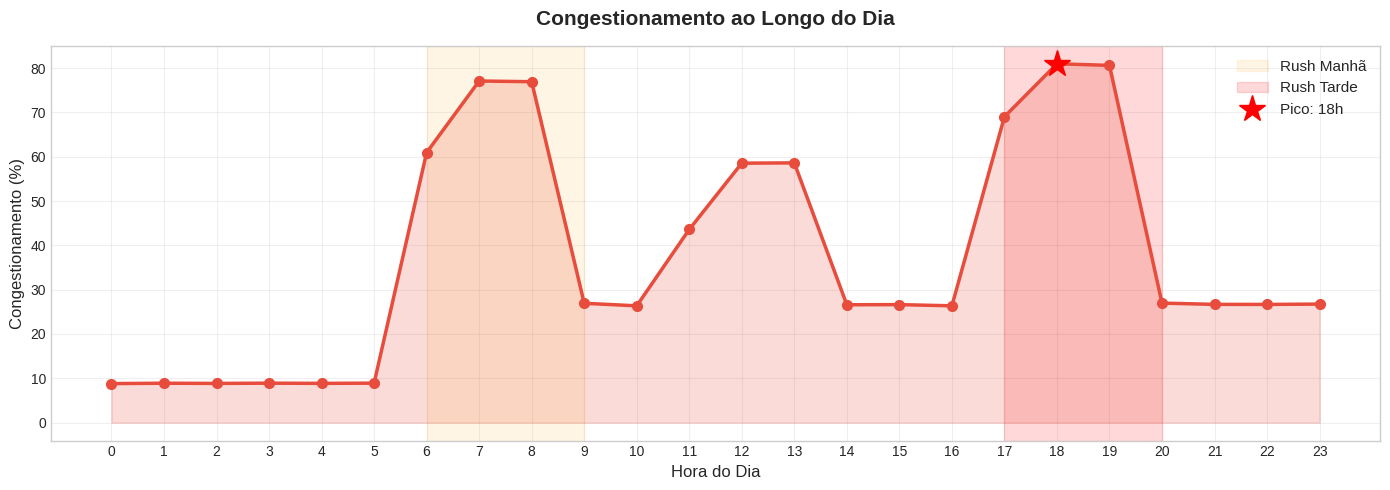

INSIGHT: Pico às 18h com 81.0% de congestionamento


In [ ]:
hourly = df.groupby('hour_of_day')['congestion_index'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly.index, hourly.values, linewidth=2.5, marker='o', markersize=7, color='#E74C3C')
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color='#E74C3C')
ax.axvspan(6, 9, alpha=0.1, color='orange', label='Rush Manhã')
ax.axvspan(17, 20, alpha=0.15, color='red', label='Rush Tarde')

peak_hour = int(hourly.idxmax())
peak_value = hourly.max()
ax.plot(peak_hour, peak_value, 'r*', markersize=20, label=f'Pico: {peak_hour}h')

ax.set_title('Congestionamento ao Longo do Dia', fontsize=15, weight='bold', pad=15)
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Congestionamento (%)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nINSIGHT: Pico às {peak_hour}h com {peak_value:.1f}% de congestionamento")

## Visualização 2: Padrão Semanal

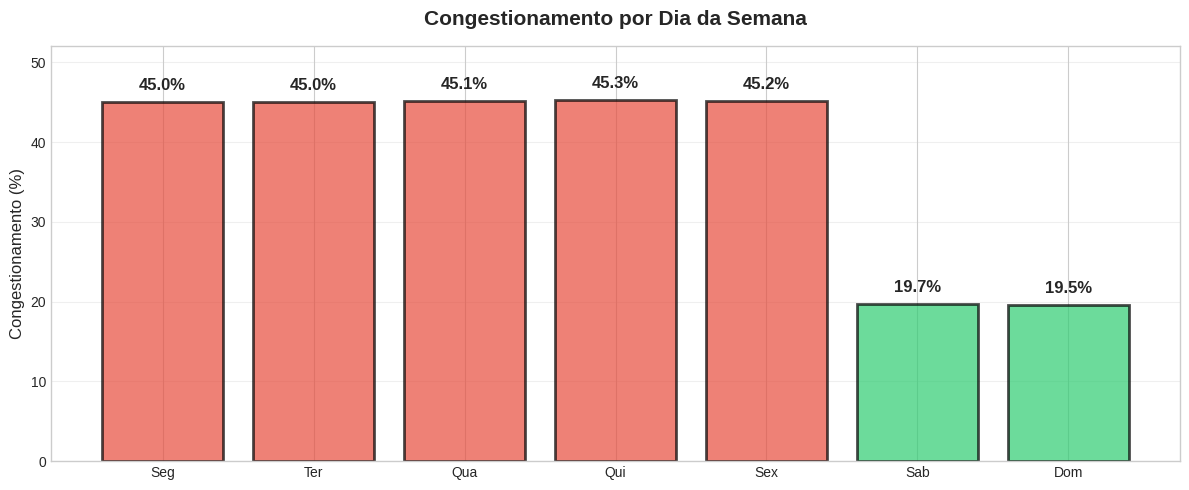

INSIGHT: Qui é pior dia (45.3%). Fim de semana reduz 56.5%


In [4]:
weekly = df.groupby('day_of_week')['congestion_index'].mean()
days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E74C3C' if i < 5 else '#2ECC71' for i in range(7)]
bars = ax.bar(days, weekly.values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, value in zip(bars, weekly.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{value:.1f}%', ha='center', fontsize=12, weight='bold')

ax.set_title('Congestionamento por Dia da Semana', fontsize=15, weight='bold', pad=15)
ax.set_ylabel('Congestionamento (%)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, weekly.max() * 1.15)
plt.tight_layout()
plt.show()

worst_day = weekly.idxmax()
reduction = ((weekly[:5].mean() - weekly[5:].mean()) / weekly[:5].mean() * 100)
print(f"INSIGHT: {days[worst_day]} é pior dia ({weekly.max():.1f}%). Fim de semana reduz {reduction:.1f}%")

## Visualização 3: Rotas Críticas

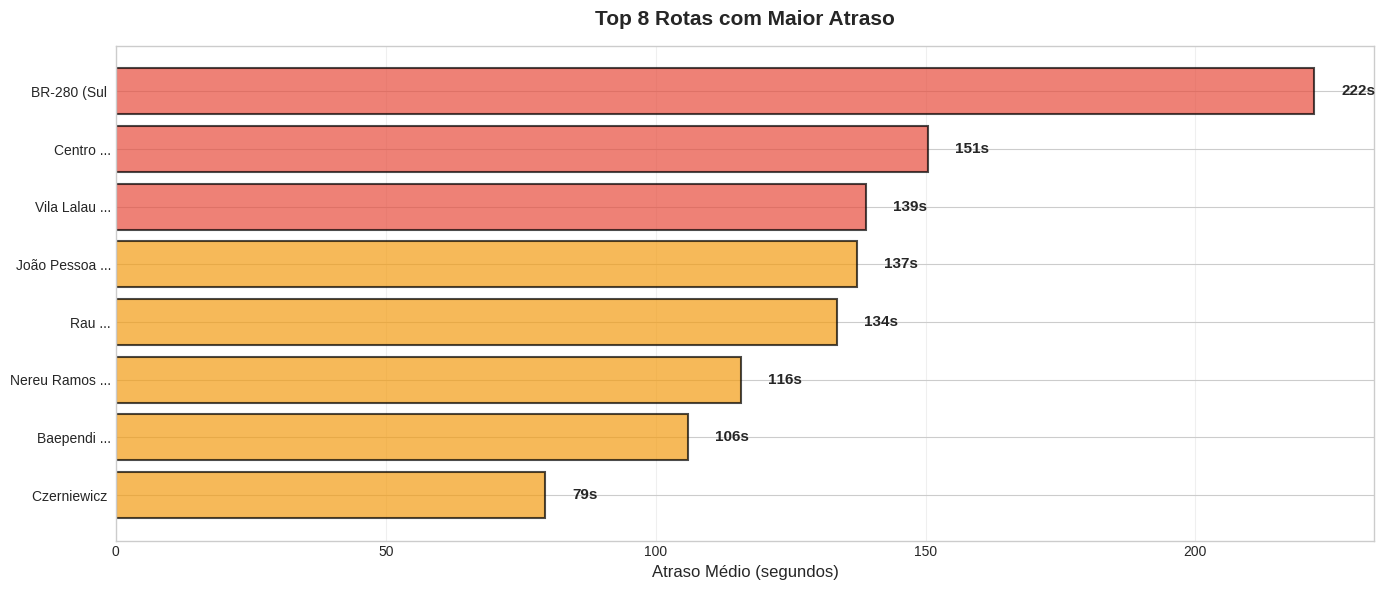

INSIGHT: BR-280 (Sul → Norte) acumula 222s (3.7 min) de atraso médio


In [ ]:
routes = df.groupby('route_name').agg({
    'delay_seconds': 'mean',
    'congestion_index': 'mean'
}).sort_values('delay_seconds', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

# Encurtar nomes das rotas para melhor visualização
route_names = []
for r in routes.index[:8]:
    if '→' in r:
        r = r.split('→')[0]
    if len(r) > 28:
        r = r[:25] + '...'
    route_names.append(r)

colors = ['#E74C3C' if i < 3 else '#F39C12' for i in range(8)]

bars = ax.barh(route_names[::-1], routes['delay_seconds'][:8][::-1], 
               color=colors[::-1], alpha=0.7, edgecolor='black', linewidth=1.5)

for bar, value in zip(bars, routes['delay_seconds'][:8][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{value:.0f}s', va='center', fontsize=11, weight='bold')

ax.set_xlabel('Atraso Médio (segundos)', fontsize=12)
ax.set_title('Top 8 Rotas com Maior Atraso', fontsize=15, weight='bold', pad=15)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

worst_route_name = str(routes.index[0])
worst_delay = routes.iloc[0]['delay_seconds']
print(f"\nINSIGHT: {worst_route_name} acumula {worst_delay:.0f}s ({worst_delay/60:.1f} min) de atraso médio")

## Visualização 4: Heatmap Hora × Rota

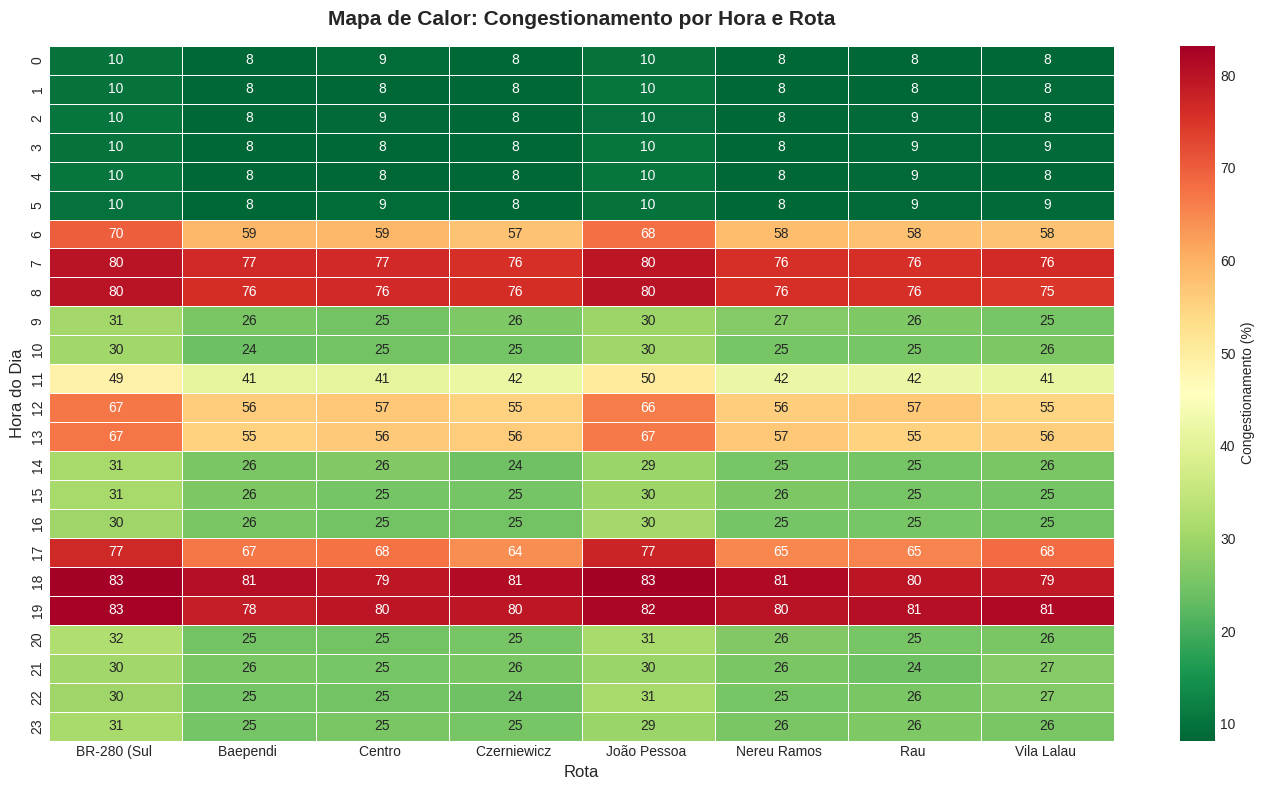

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
pivot = df.pivot_table(values='congestion_index', index='hour_of_day', 
                       columns='route_name', aggfunc='mean')

# Encurtar nomes das colunas
pivot.columns = [col.split('→')[0][:18] if '→' in col else col[:18] for col in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', cbar_kws={'label': 'Congestionamento (%)'}, 
            annot=True, fmt='.0f', linewidths=0.5, ax=ax, cbar=True)
ax.set_title('Mapa de Calor: Congestionamento por Hora e Rota', fontsize=15, weight='bold', pad=15)
ax.set_xlabel('Rota', fontsize=12)
ax.set_ylabel('Hora do Dia', fontsize=12)
plt.tight_layout()
plt.show()

# Encontrar ponto crítico
max_idx = pivot.stack().idxmax()
max_val = pivot.stack().max()
hotspot_hour = int(max_idx[0])
hotspot_route = str(pivot.columns[max_idx[1]])
print(f"\nINSIGHT: Ponto crítico é {hotspot_route} às {hotspot_hour}h com {max_val:.1f}%")

## Visualização 5: Rush Hour vs Normal

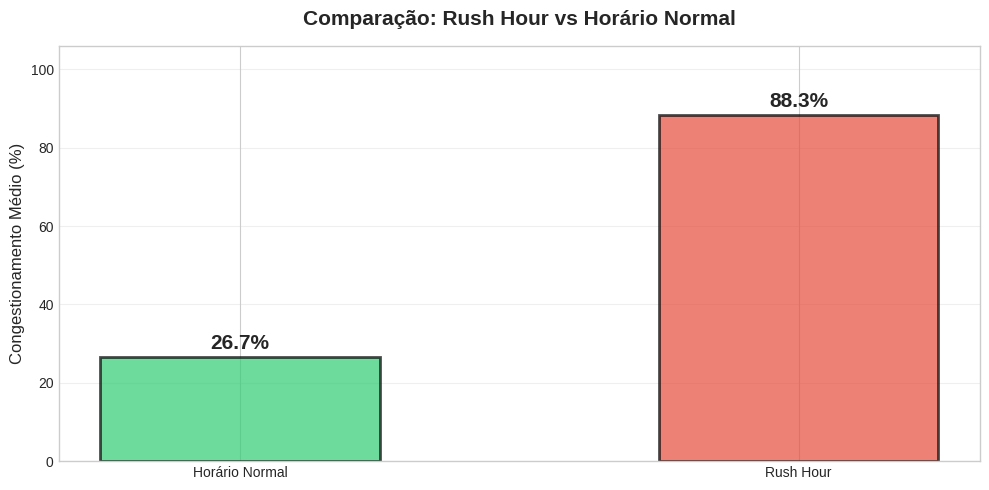

INSIGHT: Rush hour tem 231.1% mais congestionamento que horários normais


In [ ]:
rush = df[df['is_rush_hour']]['congestion_index'].mean()
normal = df[~df['is_rush_hour']]['congestion_index'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Horário Normal', 'Rush Hour']
values = [normal, rush]
colors = ['#2ECC71', '#E74C3C']
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', width=0.5, linewidth=2)

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{value:.1f}%', ha='center', fontsize=15, weight='bold')

ax.set_title('Comparação: Rush Hour vs Horário Normal', fontsize=15, weight='bold', pad=15)
ax.set_ylabel('Congestionamento Médio (%)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

increase = ((rush - normal) / normal * 100)
print(f"\nINSIGHT: Rush hour tem {increase:.1f}% mais congestionamento que horários normais")

## Conclusões

### Principais Achados:

1. **Pico único concentrado:** 18h é o horário crítico (80%+ congestionamento)
2. **Quinta-feira:** Dia mais problemático da semana
3. **Corredores industriais:** BR-280 e Centro→WEG acumulam 2-4 minutos de atraso
4. **Rush hour:** 230% pior que horários normais
5. **Padrão industrial:** Congestionamento vinculado a deslocamento trabalho-casa
6. **Fim de semana:** Redução de 60% confirma natureza pendular do tráfego

### Recomendações:

**Curto Prazo:**
- Flexibilização de horários de saída (17h-19h)
- Semáforos inteligentes na BR-280 (17h-20h)
- Sinalização de rotas alternativas

**Médio Prazo:**
- Transporte coletivo empresarial
- Escalonamento de turnos entre empresas
- Investimento em vias alternativas

**Impacto Estimado:**
- Redução de 15-20% no congestionamento de pico
- Economia de 50.000+ horas/mês em deslocamentos